# 2025-26 Corpus Baseline — Integrity, Shape, and the v1 Comparison

**Objective:** Baseline the complete 2025-26 raw corpus (#59) — run the integrity
census that gates the filter, map the season's shape, and hand each open decision its
number. Deliverable: this notebook + small derived parquets under
`data/2025-26/reference/corpus/`.

**This notebook answers:**

- §1 — Is the corpus complete and duplicate-free: safe to start `process_comments`?
- §1.2 — Is flair (the `fan_team` denominator) healthy, and does `teams.yaml` still
  match it?
- §2 — What shape was the season: daily volume, playoff multiplier, spike days?
- §3 — Is a score-weighted sentiment lens worth surfacing in v2? (spec §9.4)
- §4 — What share of the corpus lives in game threads? (the launch methodology answer
  + v3 `post_type` feasibility)
- §5 — Is r/NBA up or down YoY, and how many attributed comments should the filter
  yield?

## Load Data

Raw files are 13+ GB NDJSON, so each metric family is computed in **one pass** via
DuckDB `read_ndjson` with an explicit column spec, and the result persists as a small
parquet so no later cell (or session) rescans raw. DuckDB owns the raw scans
(out-of-core NDJSON, projection pushdown, explicit-schema tolerance of Reddit's messy
fields); Polars takes over once frames are small, via `.pl()`.

Guardrails:

- **`body` is never projected.** Column specs name only `id`, `created_utc`, `author`,
  `author_flair_text`, `score`, `link_id`, and post `title` — `body` never leaves disk.
- Every scan cell is guarded: if its derived parquet already exists, it loads instead
  of rescanning raw.
- The v1 raw file (12+ GB) is scanned **once** (§5) — the v1 dashboard parquets cover
  only attributed comments, so true v1 daily raw volumes have to come from raw.

In [1]:
import os
import sys
from datetime import date, datetime, timezone
from pathlib import Path

# Bootstrap: run from anywhere. Jupyter sets the kernel cwd to this notebook's
# folder (notebooks/2025-26/), so walk up to the project root (the dir with
# pyproject.toml), chdir there (utils.paths resolves ./data relative to cwd),
# and put it on sys.path (so `import utils` works without an editable install).
_root = Path.cwd()
while not (_root / "pyproject.toml").exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import duckdb
import matplotlib.pyplot as plt
import polars as pl

from pipeline.aggregation import extract_team_from_flair
from utils.paths import get_data_dir
from utils.season_config import get_active_season, load_season_config
from utils.team_config import build_alias_to_team_map

SEASON = "2025-26"  # pinned: this notebook is season-scoped (notebooks/2025-26/)
assert get_active_season() == SEASON, "active season flipped — review before re-running"

_cfg = load_season_config()
SEASON_START = date.fromisoformat(str(_cfg["start_date"]))
SEASON_END = date.fromisoformat(str(_cfg["end_date"]))

RAW_DIR = get_data_dir(season=SEASON) / "raw"
COMMENTS_RAW = RAW_DIR / "r_nba_comments.jsonl"
POSTS_RAW = RAW_DIR / "r_nba_posts.jsonl"
V1_COMMENTS_RAW = get_data_dir(season="2024-25") / "raw" / "r_nba_comments.jsonl"

CORPUS_DIR = get_data_dir(season=SEASON) / "reference" / "corpus"
CORPUS_DIR.mkdir(parents=True, exist_ok=True)

# The download window is ET-midnight, but day bucketing below is UTC — so the
# first UTC day carries ~20 window-hours and the last carries ~4 (verified:
# first comment 00:00:21 ET Oct 1, last 23:59:40 ET Jun 29). Census totals use
# the full window; per-day visuals and stats trim these two days so a
# windowing artifact can't read as a volume story.
EDGE_DAYS = [SEASON_START, SEASON_END]

def warn_if_stale(pq: Path, raw: Path) -> None:
    """Companion to the existence-only reuse guards: flag a persisted
    artifact older than the raw file it derives from."""
    if pq.exists() and pq.stat().st_mtime < raw.stat().st_mtime:
        print(f"WARNING: {pq.name} predates {raw.name} — delete it to force a rescan")


# Let distinct-counts spill to disk instead of failing if they outgrow RAM.
duckdb.sql("SET temp_directory = '/tmp/duckdb_corpus_spill'")

for _p in (COMMENTS_RAW, POSTS_RAW, V1_COMMENTS_RAW):
    assert _p.exists(), f"missing raw file: {_p}"

print(f"Project root: {_root}")
print(f"Season:       {SEASON}  ({SEASON_START} → {SEASON_END})")
print(f"Comments raw: {COMMENTS_RAW}  ({COMMENTS_RAW.stat().st_size / 1e9:.1f} GB)")
print(f"Posts raw:    {POSTS_RAW}  ({POSTS_RAW.stat().st_size / 1e6:.0f} MB)")
print(f"Corpus out:   {CORPUS_DIR}")

Project root: /Users/oluobiri/Documents/nba-hate-tracker
Season:       2025-26  (2025-10-01 → 2026-06-30)
Comments raw: data/2025-26/raw/r_nba_comments.jsonl  (15.0 GB)
Posts raw:    data/2025-26/raw/r_nba_posts.jsonl  (440 MB)
Corpus out:   data/2025-26/reference/corpus


## 1. Integrity census — the filter gate

One `GROUPING SETS` pass produces the global census (id uniqueness — a full-corpus
validation of #50's file-resume `+1` cursor — plus window bounds, author count, and a
null count per projected column), the daily-volume table (gap detection here; reused by
§2 and §5), *and* the flair-value table (§1.2's drift artifact) — three grains, one read.

Only the duplicate-id check is a hard assert: duplicates double-count comments through
every downstream view, so they genuinely gate the filter. Window bounds and gap days
mean "incomplete", not "corrupt" — they report and escalate via the gate verdict instead
of crashing. **`process_comments` must not start until the verdict below is PASS.**

In [2]:
# §1 scan — the ONE pass over v2 comments for the census/daily/flair family.
# Three grouping sets in a single read: (day) → daily volumes, (flair) → the
# §1.2 drift artifact, () → the global census. Only id/author/created_utc/
# author_flair_text leave disk (the guardrail bans `body`, not flair).
# epoch_ms keeps day bucketing in UTC regardless of session timezone.
CENSUS_PQ = CORPUS_DIR / "comments_census.parquet"
DAILY_PQ = CORPUS_DIR / "comments_daily.parquet"
FLAIR_PQ = CORPUS_DIR / "flair_values.parquet"
FLAIR_TOP_N = 1000  # persisted cap; the tail below it is reported, not silent

if not (CENSUS_PQ.exists() and DAILY_PQ.exists() and FLAIR_PQ.exists()):
    _scan = duckdb.sql(f"""
        SELECT
            grouping(day)   AS g_day,
            grouping(flair) AS g_flair,
            day,
            flair,
            count(*)               AS n_comments,
            count(DISTINCT id)     AS n_distinct_ids,
            count(DISTINCT author) AS n_distinct_authors,
            count(DISTINCT flair)  AS n_distinct_flairs,
            count(*) FILTER (WHERE id IS NULL)          AS null_id,
            count(*) FILTER (WHERE author IS NULL)      AS null_author,
            count(*) FILTER (WHERE created_utc IS NULL) AS null_created_utc,
            count(*) FILTER (WHERE flair IS NULL)       AS null_flair,
            min(created_utc)       AS min_utc,
            max(created_utc)       AS max_utc
        FROM (
            SELECT id, author, created_utc, author_flair_text AS flair,
                   epoch_ms(created_utc * 1000)::DATE AS day
            FROM read_ndjson('{COMMENTS_RAW}',
                format = 'newline_delimited',
                columns = {{id: 'VARCHAR', author: 'VARCHAR', created_utc: 'BIGINT',
                            author_flair_text: 'VARCHAR'}})
        )
        GROUP BY GROUPING SETS ((day), (flair), ())
    """).pl()
    _scan.filter((pl.col("g_day") == 1) & (pl.col("g_flair") == 1)).drop(
        "g_day", "g_flair", "day", "flair"
    ).write_parquet(CENSUS_PQ)
    _scan.filter(pl.col("g_day") == 0).drop("g_day", "g_flair", "flair").sort(
        "day"
    ).write_parquet(DAILY_PQ)
    _flair_rows = (
        _scan.filter((pl.col("g_flair") == 0) & pl.col("flair").is_not_null())
        .select("flair", "n_comments")
        .sort("n_comments", descending=True)
    )
    _flair_rows.head(FLAIR_TOP_N).write_parquet(FLAIR_PQ)
    print(
        f"scanned raw; census + daily + flair parquets persisted "
        f"(flair values: {_flair_rows.height:,} distinct, top {FLAIR_TOP_N} kept)"
    )
else:
    print("reusing persisted parquets (no raw rescan)")
for _pq in (CENSUS_PQ, DAILY_PQ, FLAIR_PQ):
    warn_if_stale(_pq, COMMENTS_RAW)

census = pl.read_parquet(CENSUS_PQ).row(0, named=True)
daily = pl.read_parquet(DAILY_PQ)
print(f"comments:         {census['n_comments']:,}")
print(f"distinct ids:     {census['n_distinct_ids']:,}")
print(f"distinct authors: {census['n_distinct_authors']:,}")
print(f"distinct flairs:  {census['n_distinct_flairs']:,}")

reusing persisted parquets (no raw rescan)
comments:         7,283,478
distinct ids:     7,283,478
distinct authors: 310,494
distinct flairs:  2,080


In [3]:
# §1 integrity gate. Duplicate ids are the one HARD assert — they double-count
# comments through every downstream view. Everything else reports and feeds
# the verdict: incomplete is an escalation, not a crash.
min_day = datetime.fromtimestamp(census["min_utc"], tz=timezone.utc).date()
max_day = datetime.fromtimestamp(census["max_utc"], tz=timezone.utc).date()
issues = []

# 1. Zero duplicate ids — full-corpus validation of #50's resume `+1` cursor.
assert census["n_distinct_ids"] == census["n_comments"], (
    f"{census['n_comments'] - census['n_distinct_ids']:,} duplicate ids — "
    "resume overlap? Do NOT filter this corpus."
)
print("duplicate ids: 0 (#50 resume cursor validated on the full corpus)")

# 2. Null census per projected column — reported, not asserted. A null flair is
# expected mass (unflaired users, §1.2); null id/created_utc would be malformed
# rows the filter needs to know about.
print("null counts per projected column:")
for _col in ("null_id", "null_author", "null_created_utc", "null_flair"):
    print(f"  {_col:<17} {census[_col]:>9,}")
if census["null_id"] or census["null_created_utc"]:
    issues.append("null id/created_utc rows present")

# 3. Season-window coverage — reported against config.
print(f"corpus window: {min_day} → {max_day}  (config: {SEASON_START} → {SEASON_END})")
if (min_day, max_day) != (SEASON_START, SEASON_END):
    issues.append("corpus window != configured season window")

# 4. Zero-comment-day gaps — reported count; r/NBA never has a silent day, so
# any hole is a download gap.
_spine = set(pl.date_range(min_day, max_day, interval="1d", eager=True).to_list())
_days_present = set(daily["day"].drop_nulls().to_list())
_missing = sorted(_spine - _days_present)
print(f"days present: {len(_days_present)}/{len(_spine)}; zero-comment days: {len(_missing)}")
if _missing:
    issues.append(f"{len(_missing)} gap days (first: {_missing[:5]})")

# Soft check: flag suspiciously thin days — a partial-day download wouldn't
# create a gap, but it would crater a day's volume. The two edge days are
# excluded: they're partial by construction (ET-midnight window vs UTC days),
# not by outage.
_full_days = daily.filter(~pl.col("day").is_in(EDGE_DAYS))
_median = _full_days["n_comments"].median()
_thin = _full_days.filter(pl.col("n_comments") < 0.1 * _median)
print(f"median full day: {_median:,.0f} comments; thin days (<10% of median, edges excluded): {_thin.height}")
if _thin.height:
    display(_thin)

if issues:
    print("\n§1 GATE: REVIEW — escalate before starting the filter:")
    for _i in issues:
        print(f"  - {_i}")
else:
    print("\n§1 GATE: PASS — corpus complete and duplicate-free; safe to start the filter.")

duplicate ids: 0 (#50 resume cursor validated on the full corpus)
null counts per projected column:
  null_id                   0
  null_author               0
  null_created_utc          0
  null_flair        2,705,504
corpus window: 2025-10-01 → 2026-06-30  (config: 2025-10-01 → 2026-06-30)
days present: 273/273; zero-comment days: 0
median full day: 20,631 comments; thin days (<10% of median, edges excluded): 0

§1 GATE: PASS — corpus complete and duplicate-free; safe to start the filter.


### 1.2 Flair coverage — the `fan_team` denominator

`fan_team` resolution from `author_flair_text` is the denominator behind `player_team`
and `team_overall` — every fanbase view in the product. A YoY shift in flair adoption
moves those denominators (§5 reports the YoY number), and Reddit periodically changes
flair rendering, which can silently degrade `teams.yaml` alias matching long before
aggregation would notice. So the top flair values persist as a drift-detection artifact
(`flair_values.parquet`) and run through the **production resolver** —
`pipeline.aggregation.extract_team_from_flair`, the exact function the aggregation
stage uses — so this check and production share one implementation. (Ported from the
v1 data-quality notebook, which predates `utils/team_config` and hand-rolled its
team map.)

In [4]:
# §1.2 — coverage, the drift artifact, and the production-resolver match pass.
# No raw scan here: everything derives from the §1 pass.
flair_values = pl.read_parquet(FLAIR_PQ)
flaired_n = census["n_comments"] - census["null_flair"]
flair_coverage = flaired_n / census["n_comments"]
print(f"flair coverage: {flaired_n:,} / {census['n_comments']:,} = {flair_coverage:.1%}")
print(f"distinct flair values: {census['n_distinct_flairs']:,} "
      f"(top {flair_values.height} persisted)")

# Match pass — resolve each persisted flair value exactly as aggregation will.
# map_elements is the row-wise-Python API; fine at this size (≤ FLAIR_TOP_N rows).
_team_map = build_alias_to_team_map()
flair_values = flair_values.with_columns(
    pl.col("flair")
    .map_elements(lambda f: extract_team_from_flair(f, _team_map), return_dtype=pl.String)
    .alias("resolved_team")
)
# Re-persist WITH the resolution verdict — the drift artifact should record
# what the resolver said today, so a future diff shows exactly what broke.
flair_values.write_parquet(FLAIR_PQ)

_top_total = flair_values["n_comments"].sum()
_resolved = flair_values.filter(pl.col("resolved_team").is_not_null())["n_comments"].sum()
print(f"top-value mass: {_top_total:,} comments ({_top_total / flaired_n:.1%} of all flaired)")
print(f"resolver match over that mass: {_resolved / _top_total:.1%}")

display(flair_values.head(50))

# Drift candidates: high-volume flair values the production resolver can't place.
unmatched = flair_values.filter(pl.col("resolved_team").is_null())
print(f"unmatched values in the persisted top {flair_values.height}: {unmatched.height}")
if unmatched.height:
    display(unmatched.head(20))

flair coverage: 4,577,974 / 7,283,478 = 62.9%
distinct flair values: 2,080 (top 1000 persisted)
top-value mass: 4,567,504 comments (99.8% of all flaired)
resolver match over that mass: 93.7%


flair,n_comments,resolved_team
str,i64,str
""":lal-1: Lakers""",181919,"""Los Angeles Lakers"""
""":nyk-1: Knicks""",164180,"""New York Knicks"""
""":okc-1: Thunder""",142423,"""Oklahoma City Thunder"""
""":lal-2: Lakers""",127051,"""Los Angeles Lakers"""
""":sas-5: Spurs""",126515,"""San Antonio Spurs"""
…,…,…
""":cha-2: Hornets""",27457,"""Charlotte Hornets"""
""":nyk-4: Knicks""",27387,"""New York Knicks"""
""":ind-2: Pacers""",26189,"""Indiana Pacers"""


unmatched values in the persisted top 1000: 100


flair,n_comments,resolved_team
str,i64,str
""":nba-1: NBA""",80910,null
""":sea-3: Supersonics""",24175,null
""":CAN: Canada""",15354,null
""":USA: United States""",13485,null
"""NBA""",13371,null
…,…,…
"""Australia""",2746,null
""":JPN: Japan""",2732,null
""":FIN: Finland""",2645,null


## 2. Temporal shape

Comments/day and posts/day across the season, the provisional playoff cut, and the
marquee spike days — the raw-material preview for the v2 temporal page (v1's biggest
content gap). The posts pass here is also §4's join asset: one scan, one parquet,
two consumers.

In [5]:
# Posts pass — the ONE scan of r_nba_posts.jsonl, one row per post persisted.
# posts/day (§2) and the game-thread join (§4) both derive from posts_meta.
# Title conventions are r/NBA's own: "GAME THREAD: …" (live) and
# "POST GAME THREAD: …" (recap), matched case-insensitively at title start.
# `declared_comments` is Reddit's comment count at dump time — kept as a
# cross-check against the observed link_id join, not as truth.
POSTS_PQ = CORPUS_DIR / "posts_meta.parquet"

if not POSTS_PQ.exists():
    duckdb.sql(f"""
        COPY (
            SELECT id,
                   epoch_ms(created_utc * 1000)::DATE AS day,
                   CASE
                       WHEN regexp_matches(title, '^\\s*\\[?\\s*post[ -]?game thread', 'i')
                           THEN 'post_game_thread'
                       WHEN regexp_matches(title, '^\\s*\\[?\\s*game thread', 'i')
                           THEN 'game_thread'
                       ELSE 'other'
                   END AS title_class,
                   title,
                   num_comments AS declared_comments
            FROM read_ndjson('{POSTS_RAW}',
                format = 'newline_delimited',
                columns = {{id: 'VARCHAR', created_utc: 'BIGINT',
                            title: 'VARCHAR', num_comments: 'BIGINT'}})
        ) TO '{POSTS_PQ}' (FORMAT parquet)
    """)
    print("scanned posts raw; posts_meta persisted")
else:
    print("reusing persisted posts_meta (no raw rescan)")
warn_if_stale(POSTS_PQ, POSTS_RAW)

posts = pl.read_parquet(POSTS_PQ)
assert posts["id"].n_unique() == posts.height, "duplicate post ids"
assert posts["title_class"].is_in(["game_thread", "post_game_thread", "other"]).all()
print(f"{posts.height:,} posts")
display(posts.group_by("title_class").len().sort("len", descending=True))

reusing persisted posts_meta (no raw rescan)
86,219 posts


title_class,len
str,u32
"""other""",82816
"""post_game_thread""",1860
"""game_thread""",1543


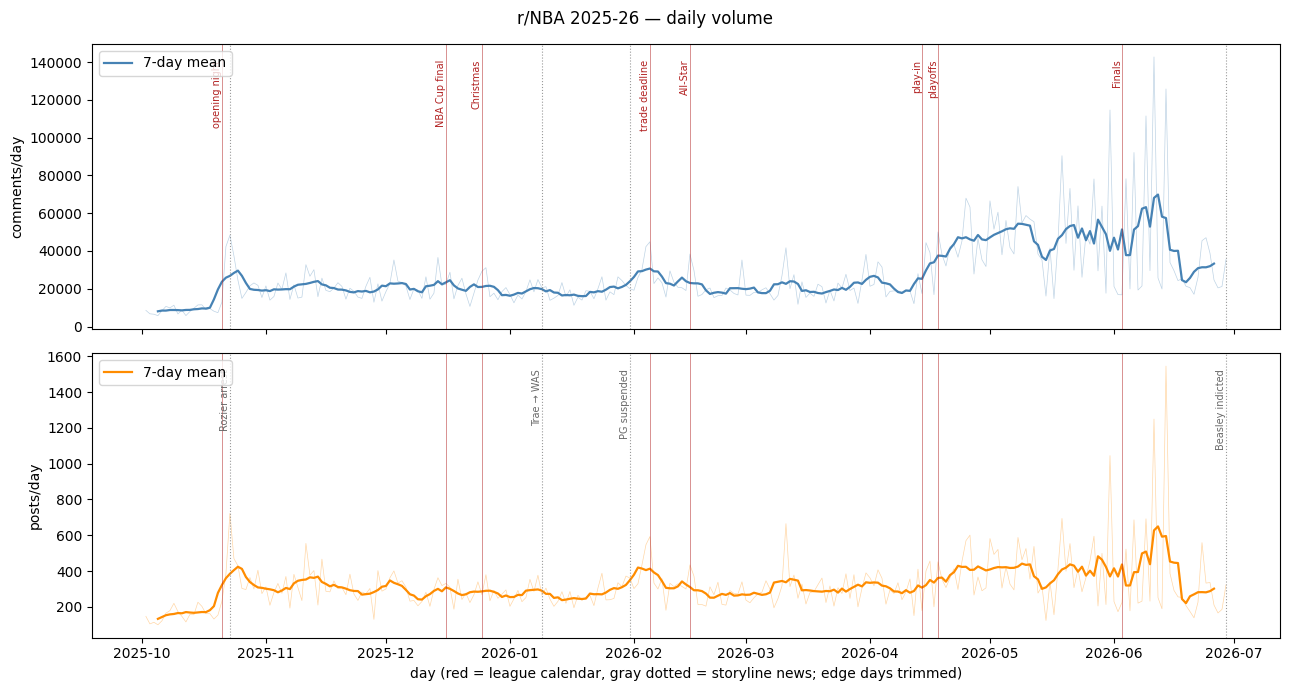

phase,days,total_comments,comments_per_day
str,u32,i64,f64
"""regular""",198,3970600,20054.0
"""playoffs""",73,3301360,45224.0


day,n_comments,dow
date,i64,str
2026-06-11,142744,"""Thu"""
2026-06-14,125791,"""Sun"""
2026-05-31,114657,"""Sun"""
2026-06-09,111513,"""Tue"""
2026-06-06,92150,"""Sat"""
2026-05-19,90436,"""Tue"""
2026-06-04,78252,"""Thu"""
2026-05-27,78136,"""Wed"""
2026-05-08,74152,"""Fri"""


In [6]:
# §2 shape. Real 2025-26 calendar drives the labels; PLAYOFF_START drives the
# phase cut (play-in Apr 14-17, playoffs Apr 18 — #52's season_phase will give
# these dates a config home).
PLAYOFF_START = date(2026, 4, 18)
EVENTS = {  # league calendar — solid lines
    date(2025, 10, 21): "opening night",
    date(2025, 12, 16): "NBA Cup final",
    date(2025, 12, 25): "Christmas",
    date(2026, 2, 5): "trade deadline",
    date(2026, 2, 15): "All-Star",
    date(2026, 4, 14): "play-in",
    date(2026, 4, 18): "playoffs",
    date(2026, 6, 3): "Finals",
}
STORYLINES = {  # tracker-relevant news (config v2.0/v3.0 storyline adds) — dotted
    date(2025, 10, 23): "Rozier arrest",
    date(2026, 1, 9): "Trae → WAS",
    date(2026, 1, 31): "PG suspended",
    date(2026, 6, 29): "Beasley indicted",
}

# Per-day visuals and stats run on full UTC days only (edge days trimmed);
# census totals in §1 keep the full window.
daily_full = daily.filter(~pl.col("day").is_in(EDGE_DAYS)).sort("day")
daily_roll = daily_full.with_columns(
    pl.col("n_comments").rolling_mean(window_size=7, center=True).alias("roll7")
)
posts_daily = (
    posts.group_by("day")
    .len()
    .rename({"len": "n_posts"})
    .filter(~pl.col("day").is_in(EDGE_DAYS))
    .sort("day")
    .with_columns(pl.col("n_posts").rolling_mean(window_size=7, center=True).alias("roll7"))
)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(daily_roll["day"], daily_roll["n_comments"], lw=0.5, alpha=0.35, color="steelblue")
axes[0].plot(daily_roll["day"], daily_roll["roll7"], lw=1.6, color="steelblue", label="7-day mean")
axes[0].set_ylabel("comments/day")
axes[0].legend(loc="upper left")
axes[1].plot(posts_daily["day"], posts_daily["n_posts"], lw=0.5, alpha=0.35, color="darkorange")
axes[1].plot(posts_daily["day"], posts_daily["roll7"], lw=1.6, color="darkorange", label="7-day mean")
axes[1].set_ylabel("posts/day")
axes[1].legend(loc="upper left")

_y0 = daily_full["n_comments"].max()
_y1 = posts_daily["n_posts"].max()
for _d, _label in EVENTS.items():
    for ax in axes:
        ax.axvline(_d, color="firebrick", lw=0.7, alpha=0.5)
    axes[0].text(_d, _y0 * 0.99, _label, rotation=90, fontsize=7, ha="right", va="top", color="firebrick")
for _d, _label in STORYLINES.items():
    for ax in axes:
        ax.axvline(_d, color="gray", lw=0.8, ls=":", alpha=0.8)
    axes[1].text(_d, _y1 * 0.99, _label, rotation=90, fontsize=7, ha="right", va="top", color="dimgray")

axes[1].set_xlabel("day (red = league calendar, gray dotted = storyline news; edge days trimmed)")
fig.suptitle(f"r/NBA {SEASON} — daily volume")
plt.tight_layout()
plt.show()

# The cheap playoff/regular cut the v2 temporal page wants (no external data).
# Edge days excluded here too, so per-day means compare full days to full days.
phase_cut = (
    daily_full.with_columns(
        pl.when(pl.col("day") >= PLAYOFF_START)
        .then(pl.lit("playoffs"))
        .otherwise(pl.lit("regular"))
        .alias("phase")
    )
    .group_by("phase")
    .agg(
        days=pl.len(),
        total_comments=pl.col("n_comments").sum(),
        comments_per_day=pl.col("n_comments").mean().round(0),
    )
    .sort("phase", descending=True)
)
display(phase_cut)

# Marquee spikes — the top-10 volume days (edge days can only under-report,
# but trimmed for consistency; annotated in the narration below).
display(
    daily_full.select("day", "n_comments")
    .sort("n_comments", descending=True)
    .head(10)
    .with_columns(pl.col("day").dt.strftime("%a").alias("dow"))
)

**Spike annotation.** All ten top-volume days are May–June playoff dates — the playoff
tide (45.2K/day vs 20.1K/day regular-era, **2.26×**, full UTC days only) swamps every
regular-season fixture. The season max (142.7K, Thu 2026-06-11) is ~7× the median full
day, inside the Finals window (Spurs–Knicks; the largest single thread is the 2026-06-10
game thread at 59.4K comments). Among regular-season days, only two crack playoff-level
volume: **Oct 23 (48.3K)** — opening week, but also the day of the Rozier arrest, and the
two can't be untangled from volume alone (the classify run can) — and **Feb 5 (44.9K)**,
the trade deadline. Christmas builds 24.6K → 31.2K across the holiday. v1's playoff
multiplier was ~2.3× (analysis doc §5); v2 holding at 2.26× says the shape carried over.

## 3. Score distributions — feeds spec §9.4

Is a score-weighted sentiment lens worth surfacing in v2? The relevant facts: how much
of the corpus carries a non-default score at all, how concentrated score is in the top
slice, and how big the negative-score mass is (weighting semantics get murky when
weights go negative). Grouping by exact score keeps the persisted artifact tiny while
preserving the full distribution — every number below is exact, not sampled.

In [7]:
# §3 scan — the ONE pass over v2 comments for the score family.
SCORES_PQ = CORPUS_DIR / "score_distribution.parquet"

if not SCORES_PQ.exists():
    duckdb.sql(f"""
        COPY (
            SELECT score, count(*) AS n
            FROM read_ndjson('{COMMENTS_RAW}',
                format = 'newline_delimited',
                columns = {{score: 'BIGINT'}})
            GROUP BY score
        ) TO '{SCORES_PQ}' (FORMAT parquet)
    """)
    print("scanned raw; score_distribution persisted")
else:
    print("reusing persisted score_distribution (no raw rescan)")
warn_if_stale(SCORES_PQ, COMMENTS_RAW)

scores = pl.read_parquet(SCORES_PQ).sort("score")
# Cross-pass consistency stays HARD (scan disagreement = corruption signal);
# null scores are census data per §1's philosophy — reported, excluded from stats.
assert scores["n"].sum() == census["n_comments"], "score-scan rows != census rows"
_null_scores = scores.filter(pl.col("score").is_null())["n"].sum()
if _null_scores:
    scores = scores.filter(pl.col("score").is_not_null())
print(f"{scores.height:,} distinct score values, {scores['n'].sum():,} comments "
      f"({_null_scores:,} null-score comments reported and excluded)")

reusing persisted score_distribution (no raw rescan)
5,396 distinct score values, 7,283,478 comments (0 null-score comments reported and excluded)


percentiles: {'p1': -14, 'p5': -2, 'p25': 1, 'p50': 2, 'p75': 6, 'p95': 48, 'p99': 265, 'p99.9': 1802}


score < 0:  590,761  (8.1%)
score == 0: 409,195  (5.6%)
score == 1: 2,191,275  (30.1%)  (1 = untouched default)
comments with score ≥ p99 (265) hold 50.6% of all positive score


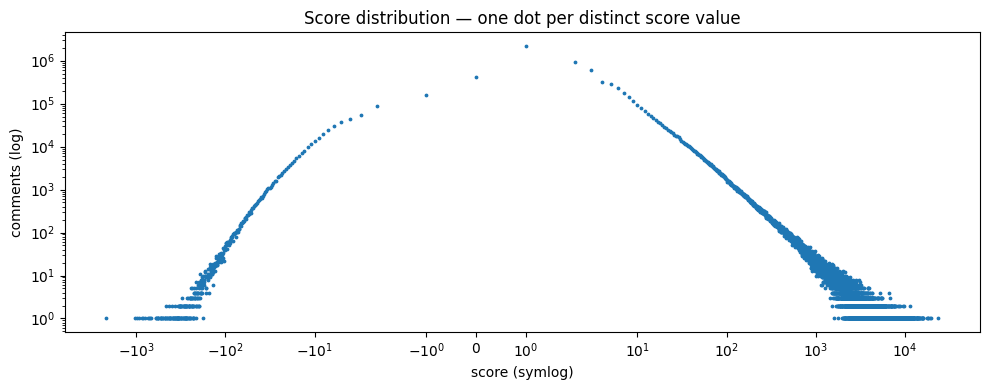

In [8]:
# §3 stats — all exact, computed from the grouped distribution.
_total = scores["n"].sum()
_cum = scores.with_columns(pl.col("n").cum_sum().alias("cum"))


def score_pctile(q: float) -> int:
    """Exact weighted percentile from the grouped score distribution."""
    return _cum.filter(pl.col("cum") >= q / 100 * _total)["score"][0]


pctiles = {q: score_pctile(q) for q in (1, 5, 25, 50, 75, 95, 99, 99.9)}
print("percentiles:", {f"p{q}": v for q, v in pctiles.items()})

neg_n = scores.filter(pl.col("score") < 0)["n"].sum()
one_n = scores.filter(pl.col("score") == 1)["n"].sum()
zero_n = scores.filter(pl.col("score") == 0)["n"].sum()
print(f"score < 0:  {neg_n:,}  ({neg_n / _total:.1%})")
print(f"score == 0: {zero_n:,}  ({zero_n / _total:.1%})")
print(f"score == 1: {one_n:,}  ({one_n / _total:.1%})  (1 = untouched default)")

# Concentration: what share of all positive score sits in the top 1% of comments?
_pos = scores.filter(pl.col("score") > 0)
pos_score_total = (_pos["score"] * _pos["n"]).sum()
p99 = pctiles[99]
top_slice = scores.filter(pl.col("score") >= p99)
top_share = (top_slice["score"] * top_slice["n"]).sum() / pos_score_total
print(f"comments with score ≥ p99 ({p99}) hold {top_share:.1%} of all positive score")

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(scores["score"], scores["n"], s=3)
ax.set_xscale("symlog")
ax.set_yscale("log")
ax.set_xlabel("score (symlog)")
ax.set_ylabel("comments (log)")
ax.set_title("Score distribution — one dot per distinct score value")
plt.tight_layout()
plt.show()

## 4. `link_id` join — comments per post, game-thread share

First empirical use of the field #43 captured. The game-thread share is (a) the direct
answer to the launch thread's top methodology question — "did this include game
threads?" (feedback §3) — and (b) the feasibility number for the v3 `post_type`
taxonomy (data-model forward look: `Post` bridges `ClassifiedComment → Game`).

In [9]:
# §4 scan — the ONE pass over v2 comments for the link_id family.
CPP_PQ = CORPUS_DIR / "comments_per_post.parquet"

if not CPP_PQ.exists():
    duckdb.sql(f"""
        COPY (
            SELECT link_id, count(*) AS n_comments
            FROM read_ndjson('{COMMENTS_RAW}',
                format = 'newline_delimited',
                columns = {{link_id: 'VARCHAR'}})
            GROUP BY link_id
        ) TO '{CPP_PQ}' (FORMAT parquet)
    """)
    print("scanned raw; comments_per_post persisted")
else:
    print("reusing persisted comments_per_post (no raw rescan)")
warn_if_stale(CPP_PQ, COMMENTS_RAW)

cpp = pl.read_parquet(CPP_PQ)
# Cross-pass consistency stays HARD (scan disagreement = corruption signal);
# null link_ids are reported per §1's philosophy and dropped from the join
# (they can't match a post).
assert cpp["n_comments"].sum() == census["n_comments"], "link-scan rows != census rows"
_null_links = cpp.filter(pl.col("link_id").is_null())["n_comments"].sum()
if _null_links:
    cpp = cpp.filter(pl.col("link_id").is_not_null())
print(f"{cpp.height:,} distinct posts commented on "
      f"({_null_links:,} null-link_id comments reported and dropped)")

reusing persisted comments_per_post (no raw rescan)
77,839 distinct posts commented on (0 null-link_id comments reported and dropped)


In [10]:
# §4 join — comment volume by post class. Comment link_id is 't3_'-prefixed;
# the posts dump id is bare.
_joined = cpp.join(
    posts.with_columns((pl.lit("t3_") + pl.col("id")).alias("link_id")),
    on="link_id",
    how="left",
)

by_class = (
    _joined.with_columns(pl.col("title_class").fill_null("(post not in dump)"))
    .group_by("title_class")
    .agg(posts=pl.len(), comments=pl.col("n_comments").sum())
    .with_columns((pl.col("comments") / census["n_comments"]).round(4).alias("comment_share"))
    .sort("comments", descending=True)
)
display(by_class)

_matched = _joined.filter(pl.col("title_class").is_not_null())
join_coverage = _matched["n_comments"].sum() / census["n_comments"]
gt_share = (
    by_class.filter(pl.col("title_class").is_in(["game_thread", "post_game_thread"]))[
        "comment_share"
    ].sum()
)
print(f"join coverage (comment's post present in posts dump): {join_coverage:.1%}")
print(f"GAME-THREAD SHARE (game + post-game, of ALL comments): {gt_share:.1%}")

# Cash the declared_comments cross-check the posts pass promised: Reddit's
# num_comments at dump time vs comments observed in the corpus, by class.
# The direction is a finding, not an assumption: late-arriving comments push
# observed above declared, removals pull it below — the ratio says which won.
declared_vs_observed = (
    _joined.filter(pl.col("title_class").is_not_null())
    .group_by("title_class")
    .agg(
        observed=pl.col("n_comments").sum(),
        declared=pl.col("declared_comments").sum(),
    )
    .with_columns((pl.col("observed") / pl.col("declared")).round(3).alias("observed_ratio"))
    .sort("declared", descending=True)
)
print("\ndeclared (Reddit's count at dump time) vs observed (comments in corpus):")
display(declared_vs_observed)
_obs, _dec = declared_vs_observed["observed"].sum(), declared_vs_observed["declared"].sum()
print(f"overall: {_obs:,} observed / {_dec:,} declared = {_obs / _dec:.1%} "
      "(the gap ≈ removed/deleted comments + drift after the post snapshot)")

# Comments-per-post distribution + the season's biggest threads.
print("\ncomments per post:")
display(
    cpp.select(
        p50=pl.col("n_comments").quantile(0.5),
        p90=pl.col("n_comments").quantile(0.9),
        p99=pl.col("n_comments").quantile(0.99),
        max=pl.col("n_comments").max(),
    )
)
display(
    _matched.sort("n_comments", descending=True)
    .head(10)
    .select("title", "title_class", "day", "n_comments")
)

title_class,posts,comments,comment_share
str,u32,i64,f64
"""other""",73416,5491337,0.7539
"""game_thread""",1464,1442757,0.1981
"""post_game_thread""",1741,340039,0.0467
"""(post not in dump)""",1218,9345,0.0013


join coverage (comment's post present in posts dump): 99.9%
GAME-THREAD SHARE (game + post-game, of ALL comments): 24.5%

declared (Reddit's count at dump time) vs observed (comments in corpus):


title_class,observed,declared,observed_ratio
str,i64,i64,f64
"""other""",5491337,5195477,1.057
"""game_thread""",1442757,1423844,1.013
"""post_game_thread""",340039,327665,1.038


overall: 7,274,133 observed / 6,946,986 declared = 104.7% (the gap ≈ removed/deleted comments + drift after the post snapshot)

comments per post:


p50,p90,p99,max
f64,f64,f64,i64
19.0,187.0,1011.0,59423


title,title_class,day,n_comments
str,str,date,i64
"""Game Thread: San Antonio Spurs…","""game_thread""",2026-06-10,59423
"""Game Thread: San Antonio Spurs…","""game_thread""",2026-05-18,44687
"""Game Thread: New York Knicks (…","""game_thread""",2026-06-13,43482
"""Game Thread: San Antonio Spurs…","""game_thread""",2026-05-30,43391
"""Game Thread: San Antonio Spurs…","""game_thread""",2026-05-20,30747
"""Game Thread: Oklahoma City Thu…","""game_thread""",2026-05-22,28504
"""Game Thread: New York Knicks (…","""game_thread""",2026-06-06,28139
"""[ Removed by moderator ]""","""other""",2026-06-09,26486
"""Game Thread: San Antonio Spurs…","""game_thread""",2026-06-08,24829


## 5. v1 vs v2 — is r/NBA up or down?

Raw totals, the daily-volume overlay, and author counts vs v1. One label to keep
straight before any number leaves this notebook: **the docs' "6.9M comments pulled" is
the *cleaned* count** (6.89M after body-validity drops — the file the v1 data-quality
notebook loaded); **true v1 raw measures 7.04M**, and everything below uses that raw
denominator (hence a 22.3% match rate where the docs said ≈23% on the cleaned basis).
Same species as the 1.57M/1.93M ambiguity, one generation later — the YoY delta is
unaffected (raw-vs-raw on both sides). Feeds launch framing and the expected
denominator for the filter's mention-match rate. This is the ONE sanctioned scan of
the v1 raw file — the v1 dashboard parquets cover only attributed comments.

In [11]:
# §5 scan — same census shape as §1 (including the flair/null columns) so the
# comparison is symmetric; no flair grouping set (v1's flair values were
# already analyzed in the v1 data-quality notebook).
V1_CENSUS_PQ = CORPUS_DIR / "v1_comments_census.parquet"
V1_DAILY_PQ = CORPUS_DIR / "v1_comments_daily.parquet"

if not (V1_CENSUS_PQ.exists() and V1_DAILY_PQ.exists()):
    _scan = duckdb.sql(f"""
        SELECT
            grouping(day) = 1  AS is_total,
            day,
            count(*)               AS n_comments,
            count(DISTINCT id)     AS n_distinct_ids,
            count(DISTINCT author) AS n_distinct_authors,
            count(DISTINCT flair)  AS n_distinct_flairs,
            count(*) FILTER (WHERE id IS NULL)          AS null_id,
            count(*) FILTER (WHERE author IS NULL)      AS null_author,
            count(*) FILTER (WHERE created_utc IS NULL) AS null_created_utc,
            count(*) FILTER (WHERE flair IS NULL)       AS null_flair,
            min(created_utc)       AS min_utc,
            max(created_utc)       AS max_utc
        FROM (
            SELECT id, author, created_utc, author_flair_text AS flair,
                   epoch_ms(created_utc * 1000)::DATE AS day
            FROM read_ndjson('{V1_COMMENTS_RAW}',
                format = 'newline_delimited',
                columns = {{id: 'VARCHAR', author: 'VARCHAR', created_utc: 'BIGINT',
                            author_flair_text: 'VARCHAR'}})
        )
        GROUP BY GROUPING SETS ((day), ())
    """).pl()
    _scan.filter(pl.col("is_total")).drop("is_total", "day").write_parquet(V1_CENSUS_PQ)
    _scan.filter(~pl.col("is_total")).drop("is_total").sort("day").write_parquet(V1_DAILY_PQ)
    print("scanned v1 raw ONCE; v1 census + daily parquets persisted")
else:
    print("reusing persisted v1 parquets (no raw rescan)")
for _pq in (V1_CENSUS_PQ, V1_DAILY_PQ):
    warn_if_stale(_pq, V1_COMMENTS_RAW)

v1_census = pl.read_parquet(V1_CENSUS_PQ).row(0, named=True)
v1_daily = pl.read_parquet(V1_DAILY_PQ)

# Right-file sanity. The docs' "6.9M" is the CLEANED count (6.89M after
# body-validity drops); TRUE raw is ~7.04M — label which denominator you mean.
assert 5_900_000 < v1_census["n_comments"] < 7_900_000, "v1 total far from expected ~7.0M raw"
print(f"v1 comments:         {v1_census['n_comments']:,}")
print(f"v1 distinct ids:     {v1_census['n_distinct_ids']:,}")
print(f"v1 distinct authors: {v1_census['n_distinct_authors']:,}")
if v1_census["n_distinct_ids"] != v1_census["n_comments"]:
    # v1 predates #50's resume fix — report, don't gate (v1 is already shipped).
    print(f"note: v1 raw carries {v1_census['n_comments'] - v1_census['n_distinct_ids']:,} duplicate ids")

reusing persisted v1 parquets (no raw rescan)
v1 comments:         7,041,235
v1 distinct ids:     7,041,235
v1 distinct authors: 300,218


v1 attributed (queried from player_overall): 1,567,722


metric,v1 (2024-25),v2 (2025-26),delta_%
str,i64,i64,f64
"""raw comments""",7041235,7283478,3.4
"""distinct authors""",300218,310494,3.4
"""days""",273,273,0.0
"""comments/day (mean)""",25792,26679,3.4


note: distinct-author counts collapse every [deleted] author into one value — the bias is identical both seasons (the YoY delta survives), but the absolute author numbers are floors, not headcounts


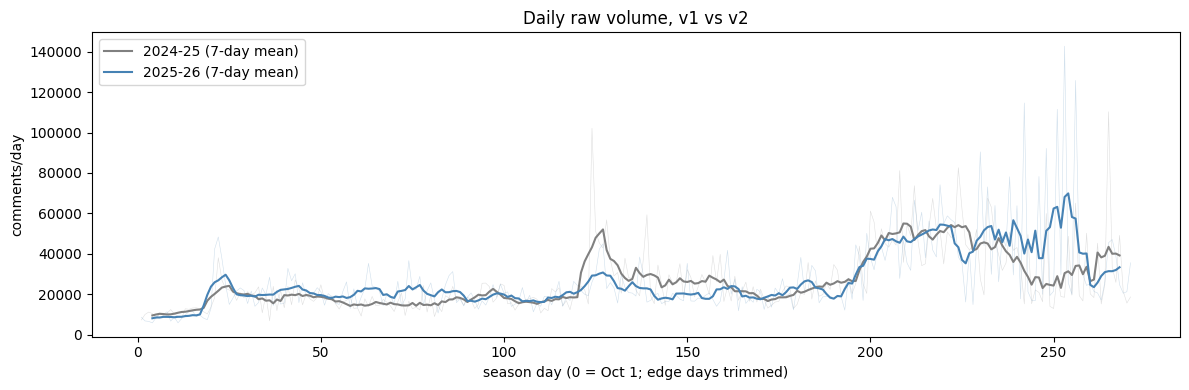

flair coverage YoY: v1 63.7% → v2 62.9% (-0.8 pp)
v1 mention-match rate: 22.3%
expected v2 attributed at v1's rate: ~1.62M (the filter's denominator expectation; config broadened since v1, so treat as a floor)


In [12]:
# §5 comparison — totals, overlay by season-day, expected filter denominator.
# The attributed baseline is QUERIED, not hardcoded (the 1.57M/1.93M lesson:
# rounded constants drift) — so it self-updates when the #47/#54 re-assembly
# shifts v1 attribution. sum(comment_count) over player_overall is the same
# "attributed" definition the launch post used.
V1_PLAYER_OVERALL = get_data_dir(season="2024-25") / "dashboard" / "player_overall.parquet"
v1_attributed = int(
    duckdb.sql(f"SELECT sum(comment_count) AS n FROM '{V1_PLAYER_OVERALL}'").pl()["n"][0]
)
v1_match_rate = v1_attributed / v1_census["n_comments"]
print(f"v1 attributed (queried from player_overall): {v1_attributed:,}")

comparison = pl.DataFrame(
    {
        "metric": ["raw comments", "distinct authors", "days", "comments/day (mean)"],
        "v1 (2024-25)": [
            v1_census["n_comments"],
            v1_census["n_distinct_authors"],
            v1_daily.height,
            round(v1_census["n_comments"] / v1_daily.height),
        ],
        "v2 (2025-26)": [
            census["n_comments"],
            census["n_distinct_authors"],
            daily.height,
            round(census["n_comments"] / daily.height),
        ],
    }
).with_columns(
    ((pl.col("v2 (2025-26)") - pl.col("v1 (2024-25)")) / pl.col("v1 (2024-25)") * 100)
    .round(1)
    .alias("delta_%")
)
display(comparison)
print("note: distinct-author counts collapse every [deleted] author into one value — "
      "the bias is identical both seasons (the YoY delta survives), but the absolute "
      "author numbers are floors, not headcounts")

# Overlay aligned by season day (0 = each season's Oct 1 window start). Both
# windows are ET-midnight bounded, so the partial-edge artifact is symmetric —
# trimmed on both sides anyway to keep the chart honest. 7-day rolling means
# carry the comparison; raw lines stay faint underneath.
_v1_edges = [v1_daily["day"].min(), v1_daily["day"].max()]
_v1 = (
    v1_daily.filter(~pl.col("day").is_in(_v1_edges))
    .sort("day")
    .with_columns(
        (pl.col("day") - v1_daily["day"].min()).dt.total_days().alias("season_day"),
        pl.col("n_comments").rolling_mean(window_size=7, center=True).alias("roll7"),
    )
)
_v2 = daily_full.with_columns(
    (pl.col("day") - SEASON_START).dt.total_days().alias("season_day"),
    pl.col("n_comments").rolling_mean(window_size=7, center=True).alias("roll7"),
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(_v1["season_day"], _v1["n_comments"], lw=0.4, alpha=0.25, color="gray")
ax.plot(_v2["season_day"], _v2["n_comments"], lw=0.4, alpha=0.25, color="steelblue")
ax.plot(_v1["season_day"], _v1["roll7"], lw=1.5, color="gray", label="2024-25 (7-day mean)")
ax.plot(_v2["season_day"], _v2["roll7"], lw=1.5, color="steelblue", label="2025-26 (7-day mean)")
ax.set_xlabel("season day (0 = Oct 1; edge days trimmed)")
ax.set_ylabel("comments/day")
ax.set_title("Daily raw volume, v1 vs v2")
ax.legend()
plt.tight_layout()
plt.show()

# Flair coverage YoY — the fan_team denominator shift (§1.2 stakes).
v1_cov = 1 - v1_census["null_flair"] / v1_census["n_comments"]
v2_cov = 1 - census["null_flair"] / census["n_comments"]
print(f"flair coverage YoY: v1 {v1_cov:.1%} → v2 {v2_cov:.1%} ({(v2_cov - v1_cov) * 100:+.1f} pp)")

expected_attributed = v1_match_rate * census["n_comments"]
print(f"v1 mention-match rate: {v1_match_rate:.1%}")
print(
    f"expected v2 attributed at v1's rate: ~{expected_attributed / 1e6:.2f}M "
    "(the filter's denominator expectation; config broadened since v1, so treat as a floor)"
)

## 6. Conclusions — decision hand-offs

**Gate (§1): PASS.** 7,283,478 comments; zero duplicate ids (#50's resume `+1` cursor
validated corpus-wide); window exactly 2025-10-01 → 2026-06-30 with 273/273 days present
and no thin full days; null census clean (the only nulls are the expected unflaired
mass). **`process_comments` is clear to start.**

**1. Game-thread share (§4) → v3 `post_type` + the launch methodology answer.**
**24.5%** of all v2 comments live in game threads (19.8% live "GAME THREAD" + 4.7%
"POST GAME THREAD"), and link_id→post join coverage is 99.9%, so the v3 `post_type`
taxonomy is fully buildable from data already on disk. The launch-thread answer
("did this include game threads?"): yes — game threads are a quarter of the corpus.
Bonus integrity note: observed comments run **104.7%** of Reddit's dump-time declared
counts — late-arriving comments outweigh removals, so the corpus is complete relative
to post snapshots, not thinned by them.

**2. Score distribution (§3) → spec §9.4 (score-weighted lens).**
Median score is 2; 30.1% of comments sit at the untouched default (1) and 5.6% at 0 —
a third of the corpus carries no crowd signal at all. Score is extremely top-heavy:
comments at/above p99 (score ≥ 265) hold **50.6% of all positive score**, so a
score-weighted lens is effectively a "what the viral threads think" lens. 8.1% of
comments are net-downvoted, and negative weights have no clean semantics in a sentiment
average. **Recommendation: bank it for v2** (no weighted counts in the views); if
revisited, cap or log-scale the weights.

**3. v1 vs v2 volume (§5) → launch framing + the filter denominator.**
r/NBA is **up 3.4%**: 7.28M vs 7.04M comments and 310K vs 300K distinct authors over
the identical 273-day window (author counts are floors — `[deleted]` collapses to one
value, identically both seasons). Reconciliation for launch content: the v1 docs'
"6.9M" is the *cleaned* count (6.89M after body-validity drops); 7.04M is true raw,
and this notebook's 22.3% match rate is raw-basis where the docs' ≈23% was
cleaned-basis — the YoY delta is raw-vs-raw and unaffected. The v1 attributed
baseline is queried live from
`player_overall` (**1,567,722**, not the rounded 1.57M), so it self-updates when
#47/#54 re-assemble v1. At v1's measured **22.3%** mention-match rate, expect
**~1.62M attributed comments as the filter's floor** — config has broadened since v1
(v3.0).

**4. Flair (§1.2) — the `fan_team` denominator is healthy.**
**62.9% of r/NBA wears a flair** (v1: 63.7%, −0.8 pp — adoption is stable, so
fanbase-view denominators are comparable YoY). The production resolver places 93.7% of
the top-value flair mass; the unmatched tail is structurally unresolvable, not drift —
generic `:nba-1: NBA`, country flags, defunct-team flairs (`:sea-3: Supersonics`) —
with no current-team format misses in the top 1000. **No `teams.yaml` action needed
before aggregation.** Drift artifact: `flair_values.parquet` (top 1000 values + today's
resolver verdict, re-diffable next season).

**Persisted artifacts** (`data/2025-26/reference/corpus/`): `comments_census`,
`comments_daily`, `flair_values`, `posts_meta`, `score_distribution`,
`comments_per_post`, `v1_comments_census`, `v1_comments_daily`.